In [ ]:
gps

grafo shape

grafo aguas

tarea redaccion figuras y tablas

# Variational Bayes

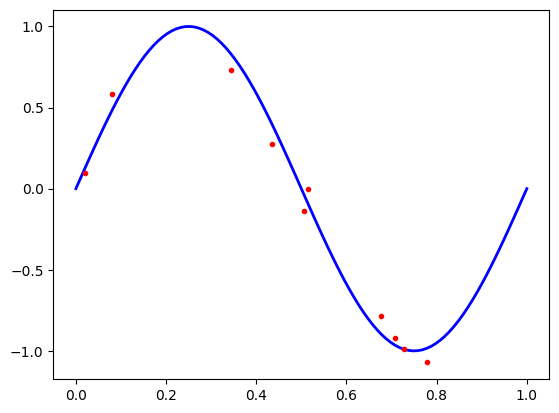

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial.distance import cdist

np.random.seed(10**4)


N_tot = 100
sigma2 = 0.01
beta = 1/sigma2
betaInv = 1/beta
x_tot = np.linspace(0, 1, num=N_tot)
y_tot = np.sin(2*np.pi*x_tot)
t_tot = y_tot + np.sqrt(betaInv)*np.random.randn(N_tot)

# Choose 60% for traininig
N = 10
index = np.random.permutation(N_tot)
t = t_tot[index[0:N]]
x = x_tot[index[0:N]]
t_test = t_tot[index[N:N_tot]]
x_test = x_tot[index[N:N_tot]]

fig, ax = plt.subplots()

ax.plot(x_tot, y_tot, 'b', x, t, '.r', linewidth=2.0)
plt.show()

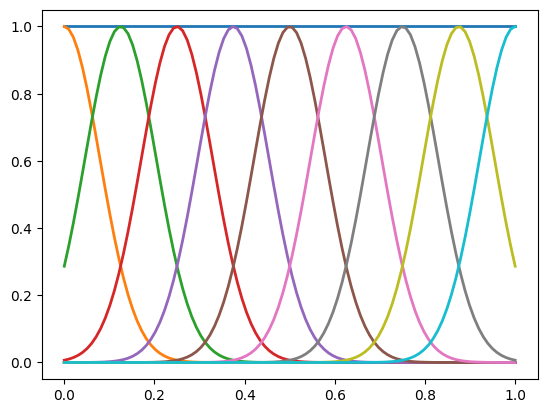

In [5]:
# Let's compute the basis functions
M = 10 # Number of basis functions
mu = np.linspace(0, 1, M-1)
aux = np.diff(mu)
s2 = 0.05*aux[0]
PHI_tot = np.zeros((N_tot, M))
PHI_tot[:, 0] = np.ones(N_tot)

for i in range(1, M):
    PHI_tot[:, i] = np.exp(-(x_tot-mu[i-1])**2/(2*s2))

fig, ax = plt.subplots()
ax.plot(x_tot, PHI_tot, linewidth=2.0)
plt.show()

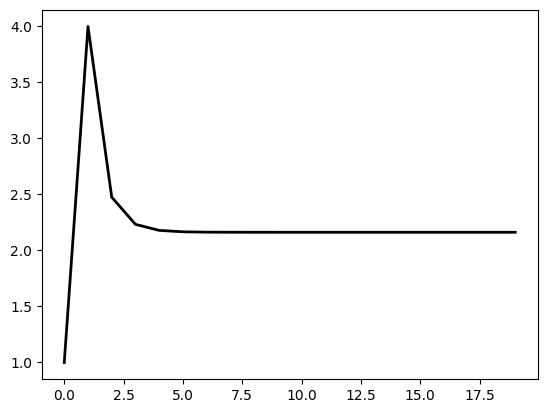

In [8]:
# Compute the basis functions only for the training data
PHI = np.zeros((N, M))
PHI[:, 0] = np.ones(N)

for i in range(1, M):
    PHI[:, i] = np.exp(-(x-mu[i-1])**2/(2*s2))

# Variational Bayes solution
niters = 20
E_alpha = 1 # Initial value for the expected value of alpha
E_wT_w = 1 # Initial value for the expected value of wT*w
a0 = 1
b0 = 1
tv = t[:, np.newaxis]
E_alphav = np.zeros(niters)
for i in range(niters):
    # Update the moments for q(alpha)
    aN = a0 + M/2
    bN = b0 + (1/2)*E_wT_w
    # Update the moments for q(w)
    E_alphav[i] = E_alpha
    E_alpha = aN/bN
    SNInv = E_alpha*np.eye(M) +  beta*(PHI.T@PHI)
    SN = np.linalg.solve(SNInv, np.eye(M))
    mN = beta*SN@PHI.T@tv;
    E_wT_w = np.trace(mN@mN.T +  SN)

# Plot the convegence of E_alpha
fig, ax = plt.subplots()
ax.plot(E_alphav, 'k', linewidth=2.0)
plt.show()

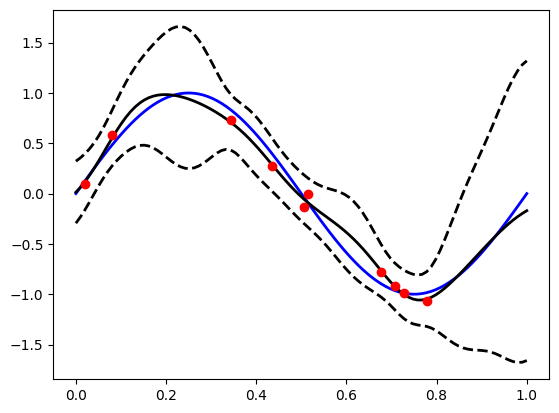

In [7]:
# Compute the predictive distribution

mpred = PHI_tot@mN;
vpred = betaInv + np.diag(PHI_tot@SN@PHI_tot.T)
fig, ax = plt.subplots()
ax.plot(x_tot, y_tot, 'b', x_tot, mpred, 'k', linewidth=2.0)
ax.plot(x_tot, mpred+2*np.sqrt(vpred[:, np.newaxis]), 'k--', linewidth=2.0)
ax.plot(x_tot, mpred-2*np.sqrt(vpred[:, np.newaxis]), 'k--', linewidth=2.0)
ax.plot(x, t, 'or')
plt.show()

# Sparse GP con GPflow

In [1]:
!pip install gpflow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 392.9/392.9 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.8/45.8 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 111.0/111.0 kB 4.4 MB/s eta 0:00:00


In [2]:
import gpflow
from gpflow.optimizers import NaturalGradient
import tensorflow as tf
from tqdm import trange
import numpy as np
import matplotlib.pyplot as plt
import os
import scipy
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
os.environ["CUDA_VISIBLE_DEVICES"] = "-1"

## Introduction

Exact Gaussian processes cannot be applied to larger training datasets because their time complexity scales with $O(n^3)$ where $n$ is the size of the training set. Approximate or sparse Gaussian processes are based on a small set of $m$ inducing variables that reduce the time complexity to $O(nm^2)$.

In this article I give an introduction to sparse Gaussian processes as described in \[1\] and provide a simple implementation with [JAX](https://github.com/google/jax). The main reason for using JAX instead of plain NumPy was the need to compute gradients of the variational lower bound. The mathematical descriptions in this article are kept on a rather high level so that the focus is on intuition rather than on a detailed derivation of equations.

### Exact Gaussian processes

In a [previous article](https://nbviewer.jupyter.org/github/krasserm/bayesian-machine-learning/blob/dev/gaussian-processes/gaussian_processes_classification.ipynb) I introduced exact Gaussian processes for regression. A Gaussian process is a [random process](https://en.wikipedia.org/wiki/Stochastic_process) where any point $\mathbf{x} \in \mathbb{R}^d$ is assigned a random variable $f(\mathbf{x})$ and where the joint distribution of a finite number of these variables $p(f(\mathbf{x}_1),...,f(\mathbf{x}_N)) = p(\mathbf{f} \mid \mathbf{X}) = \mathcal{N}(\mathbf{f} \mid \boldsymbol\mu, \mathbf{K})$ is itself Gaussian. Covariance matrix $\mathbf{K}$ is defined by a kernel function $\kappa$ where $\mathbf{K} = \kappa(\mathbf{X},\mathbf{X})$. Mean $\boldsymbol\mu$ is often set to $\mathbf{0}$. A GP can be used to define a prior over functions.

A GP prior can be converted into a posterior by conditioning on a training dataset $\mathbf{X}, \mathbf{y}$ where $\mathbf{y}$ are noisy realizations of function values $\mathbf{f}$. For independent Gaussian noise we have $y_i = f(\mathbf{x}_i) + \epsilon_i$ where $\epsilon_i \sim \mathcal{N}(0, \sigma_y^2)$. Noise-free training function values $\mathbf{f}$ are not directly observed i.e. are latent variables. The posterior over function values $\mathbf{f}_*$ at inputs $\mathbf{X}_*$ conditioned on training data is given by

$$
\begin{align*}
p(\mathbf{f}_* \mid \mathbf{X}_*,\mathbf{X},\mathbf{y}) &= \mathcal{N}(\mathbf{f}_* \mid \boldsymbol{\mu}_*, \boldsymbol{\Sigma}_*)\tag{1} \\
\boldsymbol{\mu}_* &= \mathbf{K}_*^T \mathbf{K}_y^{-1} \mathbf{y}\tag{2} \\
\boldsymbol{\Sigma}_* &= \mathbf{K}_{**} - \mathbf{K}_*^T \mathbf{K}_y^{-1} \mathbf{K}_*\tag{3}
\end{align*}
$$

where $\mathbf{K}_y = \mathbf{K} + \sigma_y^2\mathbf{I}$, $\mathbf{K}_* = \kappa(\mathbf{X},\mathbf{X}_*)$ and $\mathbf{K}_{**} = \kappa(\mathbf{X}_*,\mathbf{X}_*)$. It can be used to predict function values $\mathbf{f}_*$ at new inputs $\mathbf{X}_*$. Computation of $\boldsymbol{\mu}_*$ and $\boldsymbol{\Sigma}_*$ requires the inversion of $\mathbf{K}_y$, an $n \times n$ matrix, where $n$ is the size of the training set. Matrix inversion becomes computationally intractable for larger $n$. To outline a solution to this problem, we note that the posterior can also be defined as

$$
p(\mathbf{f}_* \mid \mathbf{y}) = \int p(\mathbf{f}_* \mid \mathbf{f}) p(\mathbf{f} \mid \mathbf{y}) d\mathbf{f} \tag{4}
$$

where the conditioning on inputs $\mathbf{X}$ and $\mathbf{X}_*$ has been made implicit. The second term inside the integral is the posterior over the training latent variables $\mathbf{f}$ conditioned on observations $\mathbf{y}$, the first term is the posterior over predictions $\mathbf{f}_*$ conditioned on latent training variables $\mathbf{f}$ (see also equation $(3)$ in [this article](https://nbviewer.jupyter.org/github/krasserm/bayesian-machine-learning/blob/dev/gaussian-processes/gaussian_processes.ipynb)). Both terms are intractable to compute for larger training datasets for reasons explained above.

### Sparse Gaussian processes

Suppose there is a small set of $m$ inducing variables $\mathbf{f}_m$ evaluated at inputs $\mathbf{X}_m$ that describe the function to be modeled "sufficiently well" then we could use them as approximation to $\mathbf{f}$ and $\mathbf{X}$ and define an approximate posterior

$$
q(\mathbf{f}_*) = \int p(\mathbf{f}_* \mid \mathbf{f}_m) \phi(\mathbf{f}_m) d\mathbf{f}_m \tag{5}
$$

where $\phi(\mathbf{f}_m)$ is an approximation to the intractable $p(\mathbf{f}_m \mid \mathbf{y})$:

$$
\phi(\mathbf{f}_m) = \mathcal{N}(\mathbf{f}_m \mid \boldsymbol{\mu}_m, \mathbf{A}_m) \tag{6}
$$

Goal is to find optimal values for mean $\boldsymbol{\mu}_m$ and covariance matrix $\mathbf{A}_m$. The quality of $\phi(\mathbf{f}_m)$ also depends on the location of the inducing inputs $\mathbf{X}_m$, hence, our goal is to find their optimal values as well. The mean and covariance matrix of the Gaussian approximate posterior $q(\mathbf{f}_*)$ are defined in terms of $\boldsymbol{\mu}_m$, $\mathbf{A}_m$ and $\mathbf{X}_m$:

$$
\begin{align*}
q(\mathbf{f}_*) &= \mathcal{N}(\mathbf{f}_* \mid \boldsymbol{\mu}_*^q, \boldsymbol{\Sigma}_*^q) \tag{7} \\
\boldsymbol{\mu}_*^q &= \mathbf{K}_{*m} \mathbf{K}_{mm}^{-1} \boldsymbol{\mu}_m \tag{8} \\
\boldsymbol{\Sigma}_*^q &= \mathbf{K}_{**} - \mathbf{K}_{*m} \mathbf{K}_{mm}^{-1} \mathbf{K}_{m*} + \mathbf{K}_{*m} \mathbf{K}_{mm}^{-1} \mathbf{A}_m \mathbf{K}_{mm}^{-1} \mathbf{K}_{m*} \tag{9}
\end{align*}
$$

where $\mathbf{K}_{mm} = \kappa(\mathbf{X}_m, \mathbf{X}_m)$, $\mathbf{K}_{*m} = \kappa(\mathbf{X}_*, \mathbf{X}_m)$ and $\mathbf{K}_{m*} = \mathbf{K}_{*m}^T$. For a single test input, this approximate posterior can be computed in $O(nm^2)$ after having found optimal values for $\boldsymbol{\mu}_m$, $\mathbf{A}_m$ and $\mathbf{X}_m$. \[1\] uses a variational approach for optimizing $\boldsymbol{\mu}_m$, $\mathbf{A}_m$ and $\mathbf{X}_m$ by minimizing the Kullback-Leibler (KL) divergence between the approximate posterior $q(\mathbf{f})$ and the exact posterior $p(\mathbf{f} \mid \mathbf{y})$ over training latent variables $\mathbf{f}$.

Minimization of this KL divergence is equivalent to maximization of a lower bound $\mathcal{L}(\boldsymbol{\mu}_m, \mathbf{A}_m, \mathbf{X}_m)$ on the true log marginal likelihood $\log p(\mathbf{y})$. This lower bound can be optimized by analytically solving for $\boldsymbol{\mu}_m$ and $\mathbf{A}_m$. The resulting lower bound after optimization is a function of $\mathbf{X}_m$:

$$
\mathcal{L}(\mathbf{X}_m) = \log \mathcal{N} (\mathbf{y} \mid \mathbf{0}, \sigma_y^2 \mathbf{I} + \mathbf{Q}_{nn}) - \frac{1}{2 \sigma_y^2} \mathrm{Tr}(\mathbf{K}_{nn} - \mathbf{Q}_{nn}) \tag{10}
$$


where $\mathbf{Q}_{nn} = \mathbf{K}_{nm} \mathbf{K}_{mm}^{-1} \mathbf{K}_{mn}$, $\mathbf{K}_{nn} = \kappa(\mathbf{X},\mathbf{X})$, $\mathbf{K}_{nm} = \kappa(\mathbf{X},\mathbf{X}_m)$ and $\mathbf{K}_{mn} = \mathbf{K}_{nm}^T$. Equation $(10)$ can be computed in $O(nm^2)$, as shown in section [Optimization](#Optimization), and used to optimize inducing inputs $\mathbf{X}_m$ jointly with kernel hyperparamaters using a numeric optimization method. The first term on the RHS is an approximate log likelihood term. Optimizing this term alone could lead to overfitting.

The second term is a regularization term which is a result of using a variational approach. This term can be interpreted as minimizing the error predicting $\mathbf{f}$ from inducing variables $\mathbf{f}_m$. The better the variables $\mathbf{f}_m$ represent the function to be modeled the smaller this error will be. Hence, optimization will try to find optimal positions for inducing inputs $\mathbf{X}_m$. With optimal values for $\mathbf{X}_m$, we can optimize $\boldsymbol{\mu}_m$ and $\mathbf{A}_m$ i.e. the parameters of $\phi(\mathbf{f}_m)$ analytically with

$$
\begin{align*}
\boldsymbol{\mu}_m &= \frac{1}{\sigma_y^2} \mathbf{K}_{mm} \boldsymbol{\Sigma} \mathbf{K}_{mn} \mathbf{y} \tag{11} \\
\mathbf{A}_m &= \mathbf{K}_{mm} \boldsymbol{\Sigma} \mathbf{K}_{mm} \tag{12}
\end{align*}
$$

where $\boldsymbol{\Sigma} = (\mathbf{K}_{mm} + \sigma_y^{-2} \mathbf{K}_{mn} \mathbf{K}_{nm})^{-1}$. $\boldsymbol{\mu}_m$ and $\mathbf{A}_m$ are then substituted into equations $(8)$ and $(9)$ to compute the approximate posterior $q(\mathbf{f}_*)$ at new inputs $\mathbf{X}_*$. This is the minimum we need to know for implementing sparse Gaussian processes for regression.

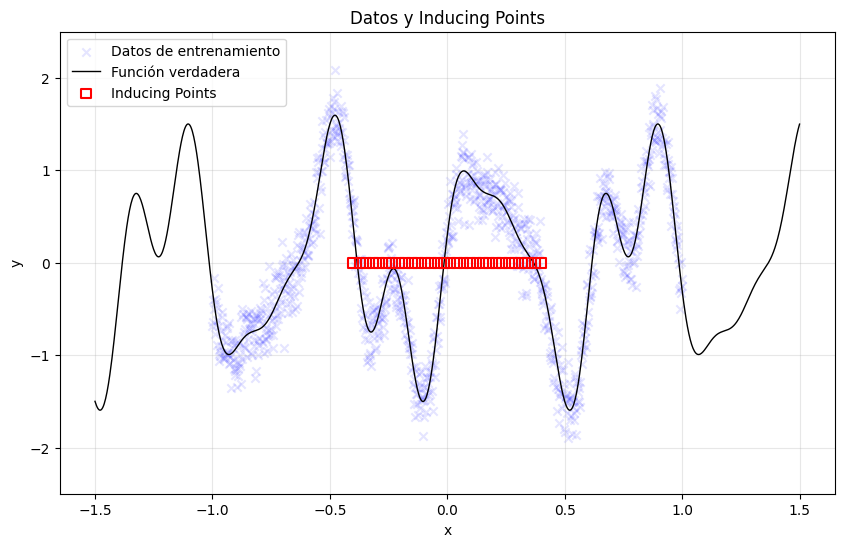

In [41]:
def func(x):
    """Latent function."""
    return 1.0 * np.sin(x * 3 * np.pi) + \
           0.3 * np.cos(x * 9 * np.pi) + \
           0.5 * np.sin(x * 7 * np.pi)


# Number of training examples
n = 1000

# Number of inducing variables
m = 30

# Noise
sigma_y = 0.2

# Noisy training data
X = np.linspace(-1.0, 1.0, n).reshape(-1, 1)
y = func(X) + sigma_y * np.random.normal(size=(n, 1))

# Test data
X_test = np.linspace(-1.5, 1.5, 1000).reshape(-1, 1)
f_true = func(X_test)

# Inducing inputs
X_m = np.linspace(-0.4, 0.4, m).reshape(-1, 1)


plt.figure(figsize=(10, 6))

# 1. Datos de entrenamiento
plt.scatter(X, y,
            label='Datos de entrenamiento',
            marker='x',
            color='blue',
            alpha=0.1)

# 2. Función latente verdadera
plt.plot(X_test, f_true,
         label='Función verdadera',
         color='black',
         linewidth=1)

# 3. Inducing Points (en el eje X)
plt.scatter(X_m,                 # Posiciones X
            np.zeros(m),        # Posiciones Y (en el base del gráfico)
            label='Inducing Points',
            marker='s',          # Marcador cuadrado
            s=50,                # Tamaño
            edgecolor='red',
            facecolor='none',
            linewidths=1.5,
            zorder=3)            # Para que aparezcan encima de otros elementos

plt.title('Datos y Inducing Points')
plt.xlabel('x')
plt.ylabel('y')
plt.ylim(-2.5, 2.5)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

A useful initial placement of inducing inputs `X_m` would be to uniformly distribute them across the entire training data region. Here, they are placed in a narrower interval for better [visualization of the optimization process](#Visualizing-the-optimization-process) later.

### Kernel

As in previous articles, we'll again use an isotropic squared exponential kernel with length parameter `theta[0]` and multiplicative constant `theta[1]`. These parameters will be optimized together with inducing inputs `X_m` as shown in the next section.

In [42]:
from gpflow.mean_functions import Linear
from gpflow.kernels import RBF
from gpflow.utilities import print_summary

# define the kernel
kernel = RBF()

# get a nice summary
print_summary(kernel, )

# define mean function
mean_f = Linear()

# get a nice summary
print_summary(mean_f, )

╒═════════════════════════════════╤═══════════╤═════════════╤═════════╤═════════════╤═════════╤═════════╤═════════╕
│ name                            │ class     │ transform   │ prior   │ trainable   │ shape   │ dtype   │   value │
╞═════════════════════════════════╪═══════════╪═════════════╪═════════╪═════════════╪═════════╪═════════╪═════════╡
│ SquaredExponential.variance     │ Parameter │ Softplus    │         │ True        │ ()      │ float64 │       1 │
├─────────────────────────────────┼───────────┼─────────────┼─────────┼─────────────┼─────────┼─────────┼─────────┤
│ SquaredExponential.lengthscales │ Parameter │ Softplus    │         │ True        │ ()      │ float64 │       1 │
╘═════════════════════════════════╧═══════════╧═════════════╧═════════╧═════════════╧═════════╧═════════╧═════════╛
╒══════════╤═══════════╤═════════════╤═════════╤═════════════╤═════════╤═════════╤═════════╕
│ name     │ class     │ transform   │ prior   │ trainable   │ shape   │ dtype   │ value   │
╞═

In [43]:
from gpflow.models import SVGP, SGPR

Z=X_m
# define GP Model
sgpr_model = SGPR(
    data=(X, y),
    kernel=kernel,
    inducing_variable=Z,
    mean_function=mean_f,
)


# get a nice summary
print_summary(sgpr_model, )

╒══════════════════════════╤═══════════╤══════════════════╤═════════╤═════════════╤═════════╤═════════╤═══════════╕
│ name                     │ class     │ transform        │ prior   │ trainable   │ shape   │ dtype   │ value     │
╞══════════════════════════╪═══════════╪══════════════════╪═════════╪═════════════╪═════════╪═════════╪═══════════╡
│ SGPR.mean_function.A     │ Parameter │ Identity         │         │ True        │ (1, 1)  │ float64 │ [[1.]]    │
├──────────────────────────┼───────────┼──────────────────┼─────────┼─────────────┼─────────┼─────────┼───────────┤
│ SGPR.mean_function.b     │ Parameter │ Identity         │         │ True        │ (1,)    │ float64 │ [0.]      │
├──────────────────────────┼───────────┼──────────────────┼─────────┼─────────────┼─────────┼─────────┼───────────┤
│ SGPR.kernel.variance     │ Parameter │ Softplus         │         │ True        │ ()      │ float64 │ 1.0       │
├──────────────────────────┼───────────┼──────────────────┼─────────┼───

### Optimization

A naive implementation of lower bound $\mathcal{L}(\mathbf{X}_m)$ as defined in equation $(10)$ is numerically unstable. A numerically stable approach is described [here](https://gpflow.github.io/GPflow/2.9.1/notebooks/theory/SGPR_notes.html#Marginal-likelihood-bound) which derives the following expression for the lower bound:

$$
\begin{align*}
\mathcal{L}(\mathbf{X}_m) =
&- \frac{n}{2} \log 2 \pi
- \frac{1}{2} \log \begin{vmatrix}\mathbf{B}\end{vmatrix}
- \frac{n}{2} \log \sigma_y^2
- \frac{1}{2 \sigma_y^2} \mathbf{y}^T \mathbf{y} \\
&+ \frac{1}{2} \mathbf{c}^T \mathbf{c}
- \frac{1}{2 \sigma_y^2} \mathrm{Tr}(\mathbf{K}_{nn})
+ \frac{1}{2} \mathrm{Tr}(\mathbf{A}\mathbf{A}^T) \tag{13}
\end{align*}
$$

where $\mathbf{c} = \mathbf{L_B}^{-1} \mathbf{A} \mathbf{y} \sigma_y^{-1}$, $\mathbf{B} = \mathbf{I} + \mathbf{A}\mathbf{A}^T$ and $\mathbf{A} = \mathbf{L}^{-1} \mathbf{K}_{mn} \sigma_y^{-1}$. Lower-triangular matrices $\mathbf{L_B}$ and $\mathbf{L}$ are obtained from a [Cholesky decomposition](https://en.wikipedia.org/wiki/Cholesky_decomposition) of $\mathbf{B} = \mathbf{L_B} \mathbf{L_B}^T$ and $\mathbf{K}_{mm} = \mathbf{L} \mathbf{L}^T$, respectively. $\mathbf{c}$ and $\mathbf{A}$ are obtained by solving the equations $\mathbf{L_B} \mathbf{c} = \mathbf{A} \mathbf{y} \sigma_y^{-1}$ and $\mathbf{L} \mathbf{A} = \mathbf{K}_{mn} \sigma_y^{-1}$, respectively. The log determinant of $\mathbf{B}$ is $2 \sum_{i=1}^m \log {L_B}_{ii}$ as explained in [this post](https://math.stackexchange.com/a/3211219/648651), for example. Using these definitions, a numerically stable implementation of a negative lower bound (`nlb`) is straightforward.

In [44]:
%%time


# define optimizer and params
minibatch_size = 128

# turn of training for inducing points
opt = gpflow.optimizers.Scipy()

# training loss
training_loss = sgpr_model.training_loss_closure()
method = "L-BFGS-B"
n_iters = 1_000

# optimize
opt_logs = opt.minimize(
    sgpr_model.training_loss,
    sgpr_model.trainable_variables,
    options=dict(maxiter=n_iters),
    method=method,
)

# print a summary of the results
print_summary(sgpr_model)

╒══════════════════════════╤═══════════╤══════════════════╤═════════╤═════════════╤═════════╤═════════╤══════════════════════╕
│ name                     │ class     │ transform        │ prior   │ trainable   │ shape   │ dtype   │ value                │
╞══════════════════════════╪═══════════╪══════════════════╪═════════╪═════════════╪═════════╪═════════╪══════════════════════╡
│ SGPR.mean_function.A     │ Parameter │ Identity         │         │ True        │ (1, 1)  │ float64 │ [[0.12943281]]       │
├──────────────────────────┼───────────┼──────────────────┼─────────┼─────────────┼─────────┼─────────┼──────────────────────┤
│ SGPR.mean_function.b     │ Parameter │ Identity         │         │ True        │ (1,)    │ float64 │ [-0.07960641]        │
├──────────────────────────┼───────────┼──────────────────┼─────────┼─────────────┼─────────┼─────────┼──────────────────────┤
│ SGPR.kernel.variance     │ Parameter │ Softplus         │         │ True        │ ()      │ float64 │ 1.03926

### Prediction

The parameters of the approximate posterior $q(\mathbf{f}_*)$ can now be computed with equations $(8)$ and $(9)$.
An approach for an implementation that scales with $O(nm^2)$ is described [here](https://gpflow.github.io/GPflow/2.9.1/notebooks/theory/SGPR_notes.html#Prediction) (note that their notation uses $q(\mathbf{u})$ instead of our $\phi(\mathbf{f}_m)$ and $p(\mathbf{f}^*)$ instead of our $q(\mathbf{f}_*)$). Here, we use a naive implementation.

In [45]:
# generate some points for plotting
X_plot = np.linspace(-1.2, 1.2, 100)[:, np.newaxis]

# predictive mean and standard deviation
y_mean, y_var = sgpr_model.predict_y(X_plot)


# convert to numpy arrays
y_mean, y_var = y_mean.numpy(), y_var.numpy()

# confidence intervals
y_upper = y_mean + 2* np.sqrt(y_var)
y_lower = y_mean - 2* np.sqrt(y_var)

# Get inducing points
Z = sgpr_model.inducing_variable.Z.numpy()

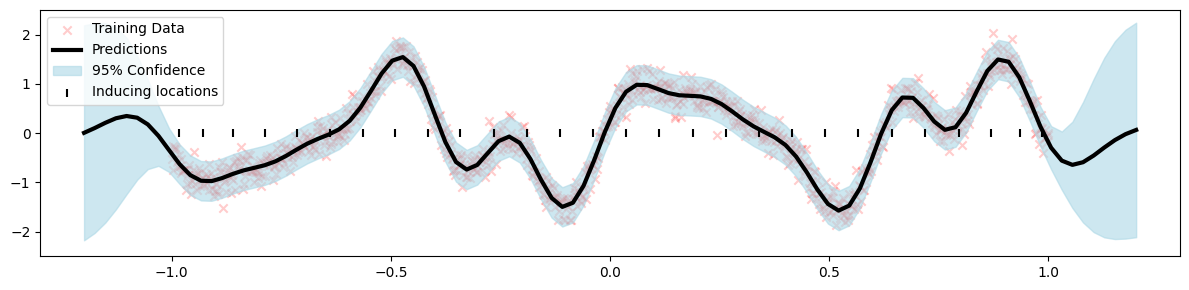

In [20]:
fig, ax = plt.subplots(figsize=(12, 3))

ax.scatter(
    X, y,
    label="Training Data",
    color='Red',
    marker='x',
    alpha=0.2
)

ax.plot(
    X_plot, y_mean,
    color='black', lw=3, label='Predictions'
)
plt.fill_between(
    X_plot.squeeze(),
    y_upper.squeeze(),
    y_lower.squeeze(),
    color='lightblue', alpha=0.6,
    label='95% Confidence'
)
plt.scatter(
    Z, np.zeros_like(Z),
    color="black", marker="|",
    label="Inducing locations"
)
plt.ylim([-2.5, 2.5])
plt.xlim([-1.3, 1.3])
plt.legend()
plt.tight_layout()
plt.show()

#Variational SGP

## GP SGP SVGP

In [46]:
from typing import Sequence

import matplotlib.pyplot as plt
import numpy as np

import gpflow

In [57]:
def plot_model(model: gpflow.models.GPModel) -> None:
    X, Y = model.data
    opt = gpflow.optimizers.Scipy()
    opt.minimize(model.training_loss, model.trainable_variables)
    gpflow.utilities.print_summary(model, "notebook")

    Xplot = np.linspace(0.0, 1.0, 200)[:, None]

    y_mean, y_var = model.predict_y(Xplot, full_cov=False)
    y_lower = y_mean - 1.96 * np.sqrt(y_var)
    y_upper = y_mean + 1.96 * np.sqrt(y_var)

    _, ax = plt.subplots(nrows=1, ncols=1)
    ax.plot(X, Y, "kx", mew=2)
    (mean_line,) = ax.plot(Xplot, y_mean, "-")
    color = mean_line.get_color()
    ax.plot(Xplot, y_lower, lw=0.1, color=color)
    ax.plot(Xplot, y_upper, lw=0.1, color=color)
    ax.fill_between(
        Xplot[:, 0], y_lower[:, 0], y_upper[:, 0], color=color, alpha=0.1
    )

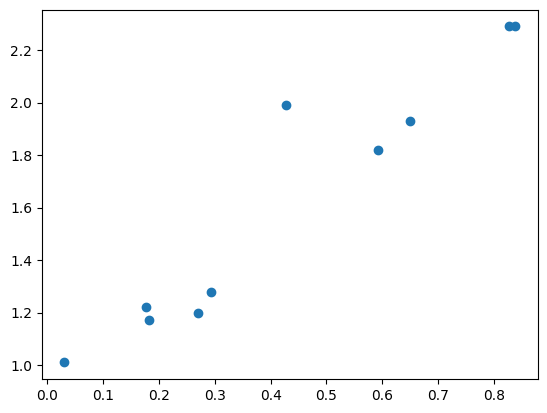

In [58]:
X = np.array(
    [
        [0.177], [0.183], [0.428], [0.838], [0.827], [0.293], [0.270], [0.593],
        [0.031], [0.650],
    ]
)
Y = np.array(
    [
        [1.22], [1.17], [1.99], [2.29], [2.29], [1.28], [1.20], [1.82], [1.01],
        [1.93],
    ]
)

plt.scatter(X, Y)

name,class,transform,prior,trainable,shape,dtype,value
GPR.kernel.variance,Parameter,Softplus,,True,(),float64,4.39101
GPR.kernel.lengthscales,Parameter,Softplus,,True,(),float64,1.60446
GPR.likelihood.variance,Parameter,Softplus + Shift,,True,(),float64,0.0243669


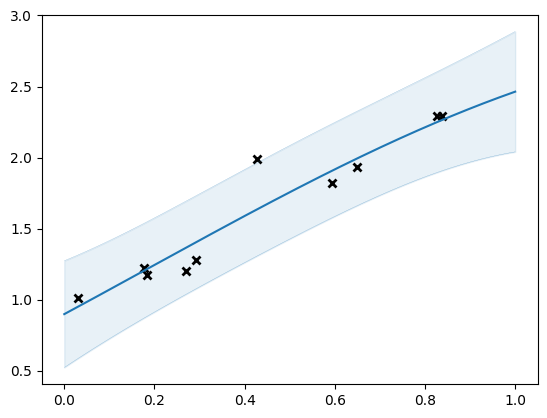

In [59]:
model: gpflow.models.GPModel = gpflow.models.GPR(
    (X, Y), kernel=gpflow.kernels.SquaredExponential()
)
plot_model(model)

name,class,transform,prior,trainable,shape,dtype,value
VGP.kernel.variance,Parameter,Softplus,,True,(),float64,5.02644
VGP.kernel.lengthscales,Parameter,Softplus,,True,(),float64,1.29313
VGP.likelihood.scale,Parameter,Softplus + Shift,,True,(),float64,0.05425654253569288
VGP.num_data,Parameter,Identity,,False,(),int32,10
VGP.q_mu,Parameter,Identity,,True,"(10, 1)",float64,[[5.17323497e-01...
VGP.q_sqrt,Parameter,FillTriangular,,True,"(1, 10, 10)",float64,"[[[1.31402012e-02, 0.00000000e+00, 0.00000000e+00..."


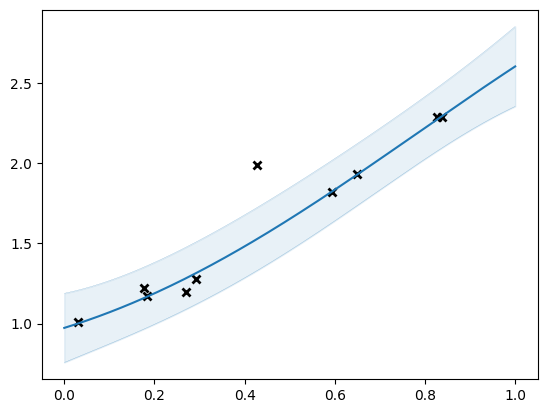

In [60]:
model = gpflow.models.VGP(
    (X, Y),
    kernel=gpflow.kernels.SquaredExponential(),
    likelihood=gpflow.likelihoods.StudentT(),
)
plot_model(model)

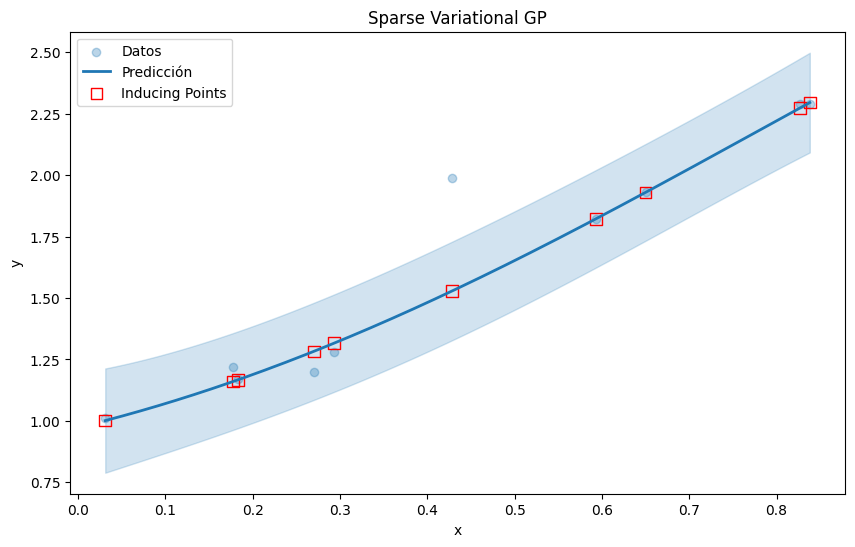

In [61]:
import gpflow
import numpy as np
import matplotlib.pyplot as plt

# 1. Definir modelo Sparse Variational GP
M = 30
Z = X[:M].copy()  # Array de NumPy

kernel = gpflow.kernels.SquaredExponential()
likelihood = gpflow.likelihoods.StudentT()

model = gpflow.models.SVGP(
    kernel=kernel,
    likelihood=likelihood,
    inducing_variable=Z
)

# 2. Entrenamiento
optimizer = gpflow.optimizers.Scipy()
maxiter = 1000

def loss_fn():
    return -model.elbo((X, Y))

optimizer.minimize(
    loss_fn,
    model.trainable_variables,
    options=dict(maxiter=maxiter)
)

# 3. Visualización corregida
def plot_model2(model, X, Y, Z):
    plt.figure(figsize=(10, 6))

    # Predicción
    X_test = np.linspace(X.min(), X.max(), 200)[:, None]
    mean, var = model.predict_y(X_test)

    # Datos
    plt.scatter(X, Y, alpha=0.3, label='Datos')
    plt.plot(X_test, mean, 'C0', lw=2, label='Predicción')
    plt.fill_between(
        X_test.flatten(),
        mean.numpy().flatten() - 2 * np.sqrt(var.numpy().flatten()),
        mean.numpy().flatten() + 2 * np.sqrt(var.numpy().flatten()),
        color='C0', alpha=0.2
    )

    # Inducing points con su posición real en Y
    mean_Z, _ = model.predict_y(Z)
    plt.scatter(Z, mean_Z,
                marker='s', s=70, edgecolor='red',
                facecolor='none', label='Inducing Points')

    plt.legend()
    plt.title('Sparse Variational GP')
    plt.xlabel('x')
    plt.ylabel('y')
    plt.show()

# Llamada corregida
plot_model2(model, X, Y, Z)

La diferencia clave entre un Sparse Gaussian Process (SGP) y un Sparse Variational Gaussian Process (SVGP) radica en cómo manejan la aproximación de la distribución posterior y cómo optimizan los parámetros. Aquí está el desglone detallado:

1. **Sparse Gaussian Process** (SGP)
Enfoque tradicional que utiliza puntos inductores (inducing points) para aproximar la matriz de covarianza.

Objetivo: Reducir la complejidad computacional $O(N^3) → O(M^3)$, donde
$M≪N%.

Método:

Selecciona puntos inductores Z (usualmente fijos o inicializados manualmente).

Aproxima la matriz de covarianza completa usando submatrices basadas en Z.

Ejemplos clásicos: FITC (Fully Independent Training Conditional), DTC (Deterministic Training Conditional).

Limitaciones:

No optimiza los puntos inductores de manera conjunta con los hiperparámetros del kernel.

Menos flexible para modelos no Gaussianos.

Puede subestimar la incertidumbre.


2. **Sparse Variational Gaussian Process (SVGP)**
Enfoque variacional que utiliza inferencia variacional para aproximar la distribución posterior.

Objetivo: Maximizar un límite inferior de la evidencia (ELBO).

Método:

Modela una distribución variacional
$q(u)$ sobre los valores de los puntos inductores
$u=f(Z)$.

Optimiza simultáneamente:

Posiciones de los puntos inductores Z.

Parámetros del kernel (e.g., longitud de escala, amplitud).

Parámetros de
$q(u)$ (media y covarianza).

Fórmula clave:
$ELBO=E
q(f)
 [logp(y∣f)]−KL(q(u)∥p(u))$
Ventajas:

Optimización conjunta de todos los parámetros.

Manejo natural de likelihoods no Gaussianos.

Mejor estimación de la incertidumbre.

# SVGP Estocastico y Colapsado

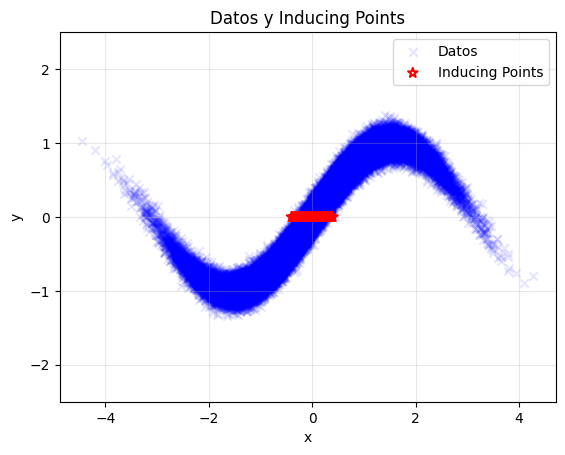

In [79]:
# Datos de ejemplo (N=1e5)
X = np.random.randn(100000, 1)
Y = np.sin(X) + 0.1 * np.random.randn(100000, 1)

# 1. Configurar modelo
M = 100  # Número de inducing points
Z = X[:M].copy()  # Inicialización de inducing points

# 1. Datos de entrenamiento
plt.scatter(X, Y,
            label='Datos',
            marker='x',
            color='blue',
            alpha=0.1)

# 3. Inducing Points (en el eje X)
plt.scatter(X_m,                 # Posiciones X
            np.zeros(m),        # Posiciones Y (en el base del gráfico)
            label='Inducing Points',
            marker='*',          # Marcador cuadrado
            s=50,                # Tamaño
            edgecolor='red',
            facecolor='none',
            linewidths=1.5,
            zorder=3)            # Para que aparezcan encima de otros elementos

plt.title('Datos y Inducing Points')
plt.xlabel('x')
plt.ylabel('y')
plt.ylim(-2.5, 2.5)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

##Estocastico
Contexto: Ideal para datasets muy grandes $\left(N>10^5\right)$ donde no es posible cargar todos los datos en memoria.

Formulación Matemática
Sea $\mathbf{u}=f(\mathbf{Z})$ los valores de la función en los inducing points $\mathbf{Z}$.
ELBO Estocástico:

$$
\mathcal{L}=\frac{N}{|\mathcal{B}|} \sum_{i \in \mathcal{B}} \mathbb{E}_{q\left(f_i\right)}\left[\log p\left(y_i \mid f_i\right)\right]-\mathrm{KL}(q(\mathbf{u}) \| p(\mathbf{u}))
$$

donde $\mathcal{B}$ es un mini-batch de datos.

In [80]:
import gpflow
import tensorflow as tf
import numpy as np

model = gpflow.models.SVGP(
    kernel=gpflow.kernels.SquaredExponential(),
    likelihood=gpflow.likelihoods.Gaussian(),
    inducing_variable=Z
)

# 2. Entrenamiento estocástico
batch_size = 1000
n_batches = 100
dataset = tf.data.Dataset.from_tensor_slices((X, Y)).repeat().shuffle(10).batch(batch_size)

optimizer = tf.optimizers.Adam(learning_rate=0.01)

@tf.function
def step(batch):
    with tf.GradientTape() as tape:
        X_batch, Y_batch = batch
        loss = -model.elbo((X_batch, Y_batch))
    grads = tape.gradient(loss, model.trainable_variables)
    optimizer.apply_gradients(zip(grads, model.trainable_variables))
    return loss

for i in range(n_batches):
    batch = next(iter(dataset))
    loss = step(batch)
    if i % 10 == 0:
        print(f"Iter {i}, ELBO: {-loss.numpy():.2f}")

Iter 0, ELBO: -1645.25
Iter 10, ELBO: -1400.02
Iter 20, ELBO: -1236.56
Iter 30, ELBO: -1130.82
Iter 40, ELBO: -1043.75
Iter 50, ELBO: -967.26
Iter 60, ELBO: -896.53
Iter 70, ELBO: -827.70
Iter 80, ELBO: -762.37
Iter 90, ELBO: -698.80


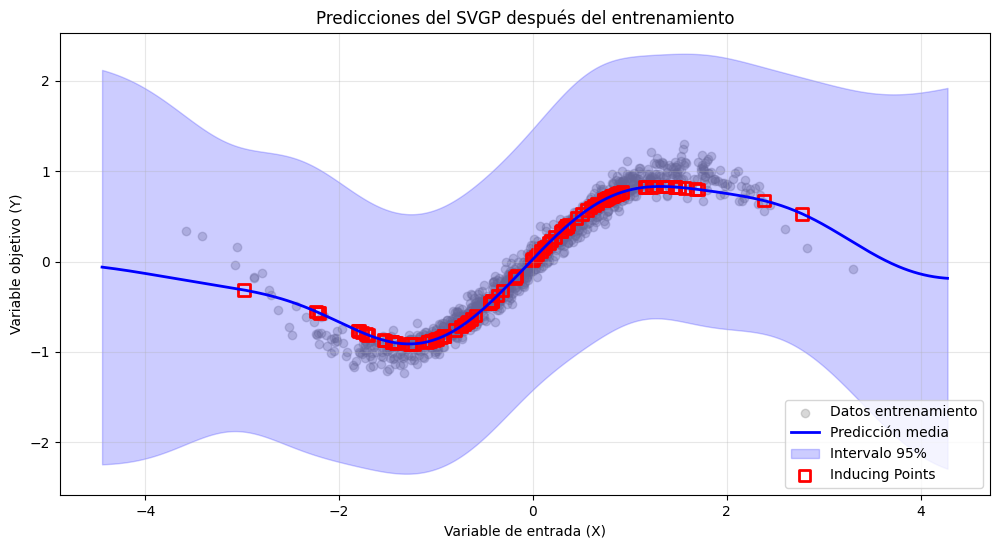

In [81]:
import matplotlib.pyplot as plt

# 1. Generar puntos de prueba
X_test = np.linspace(X.min(), X.max(), 500)[:, None]  # 500 puntos entre min y max de X

# 2. Obtener predicciones del modelo entrenado
mean, var = model.predict_y(X_test)  # Predice media y varianza (incluye ruido)

# 3. Calcular desviación estándar
std = np.sqrt(var)

# 4. Visualizar resultados
plt.figure(figsize=(12, 6))

# Datos de entrenamiento (muestra solo 1000 puntos si son muchos)
plt.scatter(X[::100], Y[::100], alpha=0.3, label='Datos entrenamiento', color='grey')

# Media predictiva
plt.plot(X_test, mean, 'b-', linewidth=2, label='Predicción media')

# Banda de incertidumbre (2 desviaciones estándar)
plt.fill_between(
    X_test.flatten(),
    (mean - 2 * std).numpy().flatten(),
    (mean + 2 * std).numpy().flatten(),
    color='blue',
    alpha=0.2,
    label='Intervalo 95%'
)

# Inducing points optimizados (posición y valor predictivo)
Z_optimized = model.inducing_variable.Z.numpy()  # Extraer posiciones optimizadas
mean_Z, _ = model.predict_y(Z_optimized)  # Media en los inducing points

plt.scatter(
    Z_optimized,
    mean_Z,
    marker='s',
    s=70,
    edgecolor='red',
    facecolor='none',
    linewidth=2,
    label='Inducing Points'
)

plt.title('Predicciones del SVGP después del entrenamiento')
plt.xlabel('Variable de entrada (X)')
plt.ylabel('Variable objetivo (Y)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Colapsado
2. SVGP Colapsado (Método de Titsias)

Contexto: Eficiente para datasets medianos ( $N \sim 10^4$ ), donde se puede optimizar analíticamente parte de la distribución variacional.

Formulación Matemática
ELBO Colapsado (Titsias, 2009):

$$
\mathcal{L}=\log \mathcal{N}\left(\mathbf{y} \mid \mathbf{0}, \mathbf{K}_{f u} \mathbf{K}_{u u}^{-1} \mathbf{K}_{u f}+\sigma^2 \mathbf{I}\right)-\frac{1}{2 \sigma^2} \operatorname{tr}\left(\mathbf{K}_{f f}-\mathbf{K}_{f u} \mathbf{K}_{u u}^{-1} \mathbf{K}_{u f}\right)
$$

donde:
- $\mathbf{K}_{u u}$ : Kernel en los inducing points
- $\mathbf{K}_{f u}$ : Kernel cruzado entre datos e inducing points

In [84]:
import gpflow
import numpy as np

model = gpflow.models.SGPR(
    data=(X, Y),
    kernel=gpflow.kernels.SquaredExponential(),
    inducing_variable=Z
)

# 2. Optimización analítica parcial
gpflow.set_trainable(model.inducing_variable, True)  # Optimizar Z
gpflow.set_trainable(model.likelihood.variance, True)

# 3. Entrenamiento
optimizer = gpflow.optimizers.Scipy()
optimizer.minimize(
    model.training_loss,
    variables=model.trainable_variables,
    options=dict(maxiter=1000)
)


print("Lower bound: %f" % model.elbo().numpy())
print("Upper bound: %f" % model.upper_bound().numpy())

print("Parámetros óptimos:")
print(f" - Length-scale: {model.kernel.lengthscales.numpy():.2f}")
print(f" - Inducing points: {model.inducing_variable.Z.numpy()[:5]}")

Lower bound: 88423.253860
Upper bound: 110182.615135
Parámetros óptimos:
 - Length-scale: 2.31
 - Inducing points: [[ 0.28988579]
 [ 1.18519754]
 [ 0.91097747]
 [-1.48097371]
 [ 1.57220408]]


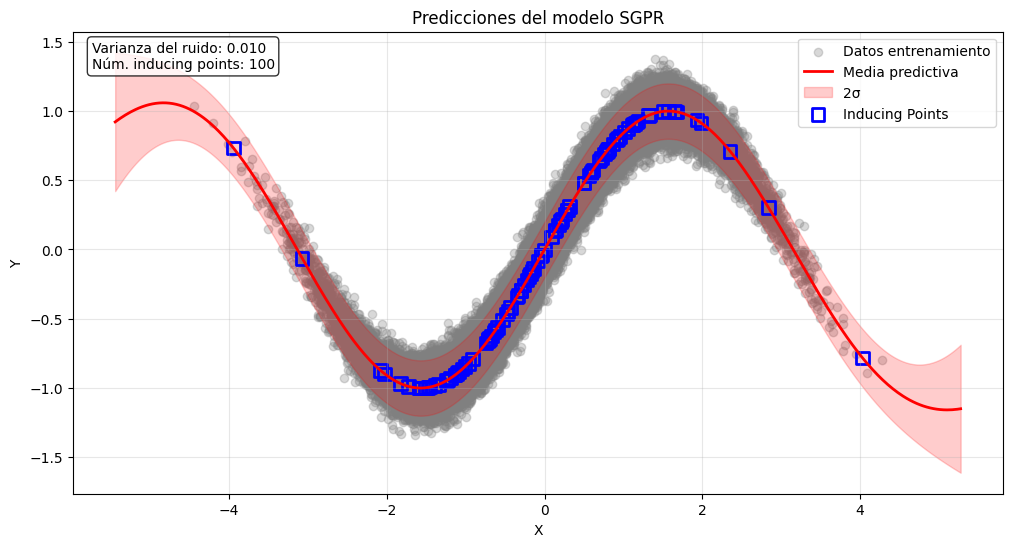

In [94]:
import matplotlib.pyplot as plt

# 1. Generar puntos para predicción
X_test = np.linspace(X.min() - 1, X.max() + 1, 500)[:, None]  # Extender rango

# 2. Obtener predicciones
mean, var = model.predict_y(X_test)  # Predicción incluyendo ruido
std = np.sqrt(var)

# 3. Visualización
plt.figure(figsize=(12, 6))

# Datos de entrenamiento
plt.scatter(X, Y, alpha=0.3, label='Datos entrenamiento', color='grey')

# Media predictiva
plt.plot(X_test, mean, 'r-', lw=2, label='Media predictiva')

# Intervalo de confianza (95%)
plt.fill_between(X_test.flatten(),
                 (mean - 2*std).numpy().flatten(),
                 (mean + 2*std).numpy().flatten(),
                 color='red', alpha=0.2, label='2σ')

# Inducing points optimizados con sus valores predichos
Z_opt = model.inducing_variable.Z.numpy()
mean_Z, _ = model.predict_y(Z_opt)

plt.scatter(Z_opt, mean_Z,
            s=80, edgecolor='blue', facecolor='none',
            linewidth=2, marker='s', label='Inducing Points')

# Añadir información de parámetros
textstr = '\n'.join((
    # f'Length-scale: {model.kernel.lengthscales.numpy()[0]:.2f}',
    f'Varianza del ruido: {model.likelihood.variance.numpy():.3f}',
    f'Núm. inducing points: {Z_opt.shape[0]}'))
plt.gca().text(0.02, 0.98, textstr, transform=plt.gca().transAxes,
              fontsize=10, verticalalignment='top',
              bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.title('Predicciones del modelo SGPR')
plt.xlabel('X')
plt.ylabel('Y')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()